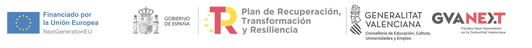

# Examen segundo parcial SAA

*  En este examen hay una parte de programación y dos problemas teórico-prácticos.
*  Dentro de la programación vamos a tener distintas preguntas.
*  Se deberá entregar el fichero en formato ipynb y pdf.
*  En nombre del fichero debe de tener el siguiente formato: NOMBRE_APE1_APE2
*  Se puede utilizar el prácticas, examanees anteriores y apuntes de la asignatura.
*  **No se puede utilizar  ninguna clase de IA generativa.**
*  Se valorará la originalidad de los experimentos, haciéndose mucho hincapié en la calidad de la conclusión de los mismos.
*  Se tendrá en cuenta positivamente aquellos modelos con mejor desempeño y resueltos con el menor numero de épocas-.
*  Duración máxima 2 horas.

## **Programación**

Hemos escogido para este laboratorio el dataset **MNIST** (dígitos escritos a mano del 0 al 9).
Es un problema sencillo de entrenar por lo que nuestros modelos deben de entrenarse de una forma rápida.
Lee atentamente los enunciados, en cada pregunta te aparecerá lo que vale.

Descargamos dataset y visualizamos.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28) y_train shape: (60000,)
x_test shape: (10000, 28, 28) y_test shape: (10000,)


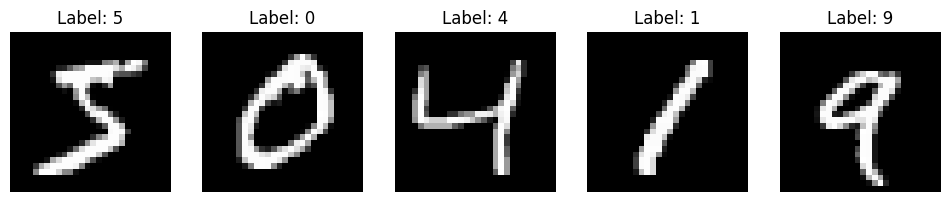

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping

# Cargamos el dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape, "y_test shape:", y_test.shape)

# Visualizamos algunas imágenes
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

In [2]:
# Reshape para que tenga el canal
w, h = 28, 28
x_train = x_train.reshape(x_train.shape[0], w, h, 1)
x_test = x_test.reshape(x_test.shape[0], w, h, 1)

print(x_train.shape[0], 'train set')
print(x_test.shape[0], 'test set')
print("Shape:", x_train.shape)

60000 train set
10000 test set
Shape: (60000, 28, 28, 1)


### **Preparación de datos**

#### 1) Realiza las siguientes operaciones de preparación de datos: (0,25 puntos) (RA5)

a) Normaliza las imágenes.

b) Analiza la distribución de clases del dataset. ¿Existe sesgo? Si lo hubiera, ¿qué acciones tomarías para solucionarlo?

c) Baraja aleatoriamente los datos de entrenamiento. ¿Por qué es importante este paso?

In [3]:
# Normalización
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Rango de valores x_train normalizado: Min {np.min(x_train)} - Max {np.max(x_train)}")

Rango de valores x_train normalizado: Min 0.0 - Max 1.0


In [26]:
import numpy as np

# Contamos el número de ocurrencias por cada clase en el conjunto de entrenamiento
clases, conteos = np.unique(y_train, return_counts=True)

print("Distribución de clases en el conjunto de entrenamiento:")
for clase, conteo in zip(clases, conteos):
    print(f"{clase}: {conteo} muestras")

Distribución de clases en el conjunto de entrenamiento:
0: 5923 muestras
1: 6742 muestras
2: 5958 muestras
3: 6131 muestras
4: 5842 muestras
5: 5421 muestras
6: 5918 muestras
7: 6265 muestras
8: 5851 muestras
9: 5949 muestras


In [5]:
# No hay clases desbalanceadas, ya que cada clase (0-9) tiene aproximadamente el mismo número de muestras (alrededor de 6000 cada una).

# En caso de haber clases desbalanceadas, podríamos aplicar técnicas como:

# Aumentar el peso a las clases minoritarias, dando más importancia a aquellas que no tienen tantas muestras
# Aumentar las clases minoritarias
# Reducir las clases mayoritarias

In [6]:
# Generamos índices aleatorios y reordenamos X e Y a la vez para no perder la correspondencia
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

In [7]:
# Es importante barajar los datos de entrenamiento para evitar ciertas cosas:

# No queremos "spoilers": Si el modelo sabe que después de una manzana siempre viene otra manzana, dejará de analizar los píxeles y solo seguirá el orden.

# Ensalada de datos: Al barajar, cada "bocado" (lote o batch) que la IA prueba tiene un poco de todo. Esto hace que el aprendizaje sea estable.

### **Experimento 1 — Red Fully Connected**

#### 2) Crea una red neuronal Fully Connected (Dense) capaz de superar el 90 % en val_accuracy. No se permite utilizar capas convolucionales. Utiliza el optimizador Adam. (1 puntos) (RA5)



In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

# No se permiten capas convolucionales
exp1 = Sequential([
    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')

])

# 2. Compilación del modelo
# Usamos 'sparse_categorical_crossentropy' porque las etiquetas (y_train) son enteros (0-9)
exp1.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Entrenamiento del modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_exp1 = exp1.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Usamos el 20% del train para validación y medir el val_accuracy
    callbacks=[early_stop]
)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8842 - loss: 0.3972 - val_accuracy: 0.9430 - val_loss: 0.2033
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9416 - loss: 0.1992 - val_accuracy: 0.9580 - val_loss: 0.1473
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9552 - loss: 0.1517 - val_accuracy: 0.9654 - val_loss: 0.1211
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9610 - loss: 0.1280 - val_accuracy: 0.9688 - val_loss: 0.1096
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9671 - loss: 0.1100 - val_accuracy: 0.9700 - val_loss: 0.1025
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9703 - loss: 0.0971 - val_accuracy: 0.9718 - val_loss: 0.0937
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9719 - loss: 0.0890 - val_accuracy: 0.9720 - val_loss: 0.0925
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9749 - loss: 0.0793 - val_accuracy: 0.

#### 3) Crea una estructura de tabla de experimentación y funciones de visualización para comparar val_accuracy por epochs entre los distintos experimentos. (0.25 puntos) (RA5)

Funciones para gráficas.

In [9]:
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], '--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento ' + name1, 'Validación ' + name1,
                'Entrenamiento ' + name2, 'Validación ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], '--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()

Tabla de experimentación.

In [10]:
from prettytable import PrettyTable

def registrar_experimento(tabla, history_obj, nombre_exp, descripcion):
    """
    Extrae los mejores resultados de un objeto history de Keras,
    los añade a la tabla y la imprime.
    """
    # 1. Encontrar el índice de la época con el mejor validation accuracy
    # Usamos .history['val_accuracy'] que es la lista de métricas por época
    indice_mejor_val_acc = np.argmax(history_obj.history['val_accuracy'])

    # 2. Extraer los valores de esa época específica
    acc = history_obj.history['accuracy'][indice_mejor_val_acc]
    loss = history_obj.history['loss'][indice_mejor_val_acc]
    val_acc = history_obj.history['val_accuracy'][indice_mejor_val_acc]
    val_loss = history_obj.history['val_loss'][indice_mejor_val_acc]

    # 3. Añadir la fila a la tabla redondeando a 4 decimales
    tabla.add_row([
        nombre_exp,
        descripcion,
        f"{acc:.4f}",
        f"{loss:.4f}",
        f"{val_acc:.4f}",
        f"{val_loss:.4f}"
    ])

    # 4. Imprimir la tabla actualizada
    print(tabla)

In [11]:
# Inicializas la tabla
mi_tabla = PrettyTable(["Experimento", "Descripción", "Accuracy", "Loss", "Val_Accuracy", "Val_Loss"])

In [12]:
# 1. Registrar el Experimento 1 en la tabla
registrar_experimento(mi_tabla,
                      history_exp1,
                      "Experimento 1",
                      "Fully Connected, Adam, NO Convulucionales")

+---------------+-------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                Descripción                | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+-------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | Fully Connected, Adam, NO Convulucionales |  0.9820  | 0.0549 |    0.9772    |  0.0821  |
+---------------+-------------------------------------------+----------+--------+--------------+----------+


### **Experimento 2 — Red Convolucional**

#### 4) Ahora crea una red neuronal **Convolucional (CNN)** para el mismo problema. Debe superar el **96 %** en val_accuracy. Utiliza el optimizador SGD. (1.5 puntos) (RA5)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# 1. Definición de la arquitectura CNN
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(), # Vital para acelerar la convergencia con SGD en pocas epochs
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# 2. Compilación del modelo
# Usamos 'sparse_categorical_crossentropy' porque las etiquetas (y_train) son enteros (0-9)
model_cnn.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Entrenamiento del modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Usamos el 20% del train para validación y medir el val_accuracy
    callbacks=[early_stop]
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9270 - loss: 0.2511 - val_accuracy: 0.9712 - val_loss: 0.1086
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9716 - loss: 0.1014 - val_accuracy: 0.9796 - val_loss: 0.0695
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9779 - loss: 0.0752 - val_accuracy: 0.9839 - val_loss: 0.0584
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9821 - loss: 0.0627 - val_accuracy: 0.9843 - val_loss: 0.0519
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9845 - loss: 0.0540 - val_accuracy: 0.9844 - val_loss: 0.0496
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9866 - loss: 0.0471 - val_accuracy: 0.9858 - val_loss: 0.0464
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9880 - loss: 0.0424 - val_accuracy: 0.9859 - val_loss: 0.0436
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9887 - loss: 0.0389 - val_accuracy: 0.

In [14]:
# Registrar el Experimento 2 en la tabla
registrar_experimento(mi_tabla,
                      history_cnn,
                      "Experimento 2",
                      "CNN, BatchNormalization, Optimizador SGD y Dropout al 0.3")

+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                        Descripción                        | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 |         Fully Connected, Adam, NO Convulucionales         |  0.9820  | 0.0549 |    0.9772    |  0.0821  |
| Experimento 2 | CNN, BatchNormalization, Optimizador SGD y Dropout al 0.3 |  0.9931  | 0.0250 |    0.9893    |  0.0370  |
+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+


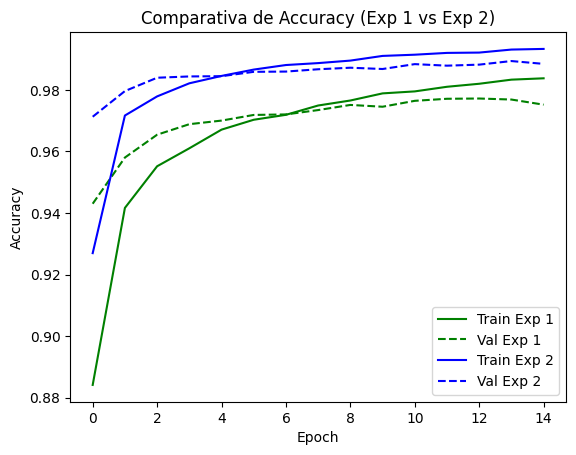

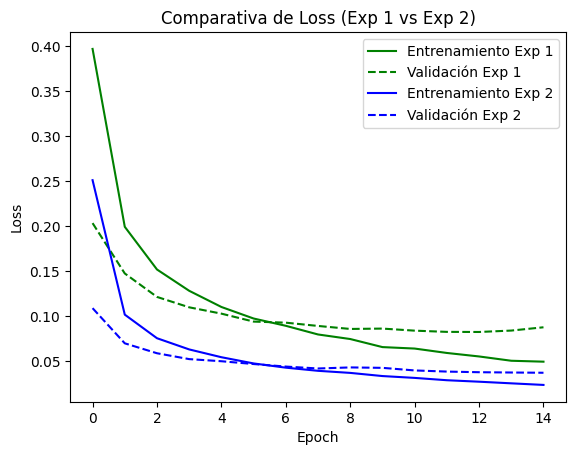

In [15]:
plot_compare_accs(history_exp1, history_cnn, name1="Exp 1", name2="Exp 2", title="Comparativa de Accuracy (Exp 1 vs Exp 2)")
plot_compare_losses(history_exp1, history_cnn, name1="Exp 1", name2="Exp 2", title="Comparativa de Loss (Exp 1 vs Exp 2)")

#### 5) Compara ambos modelos (Fully Connected vs CNN) mediante tabla y gráfica. Realiza una conclusión del experimento respondiendo a las siguientes preguntas: (RA6)

- ¿Cuál de los dos modelos ha obtenido mejores resultados? (0.25 puntos)
- ¿A nivel de computación por qué las CNN son más adecuadas para problemas de visión por computador que las redes Fully Connected?(1 puntos)

In [16]:
# Quien ha obtenido mejores resultados es el experimento 2
# por estos motivos:

# 1. Preserva Estructura Espacial
# Las CNN analizan la imagen en 2D detectando patrones locales

# 2. Eficiencia de parámetros
# Los filtros se deslizan por toda la imagen --> Muchos menos pesos
# entrenables que una capa densa colmpleta, luego tenemos un modelo
# más rápido y menos propenso al overfitting

# 3.Invarianza a la traslación
# El MaxPooling reduce la dimensionalidad y permite reconocer un objeto
# independientemente de su posición en la imagen.

# 4. Extracción Jerárquica
# Las primeras capas detectan los bordes, las intermedias texturas
# y las profundas formas complejas

# Las CNN son esenciales en el aprendizaje con imagenes


- ¿Cuál tiene más parámetros entrenables? ¿Por qué?(0.25 puntos)

In [17]:
exp1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (64, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [18]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (64, 26, 26, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (64, 26, 26, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (64, 13, 13, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (64, 11, 11, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (64, 11, 11, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (64, 5, 5, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (64, 1600)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, 128)              │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (64, 128)              │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,932 (882.55 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

In [19]:
# El modelo CNN (experimento 2) tiene más parámetros entrenables (225,482 vs 101,770).
# Sin embargo, esto NO se debe principalmente a las capas convolucionales (que de hecho
# tienen muy pocos parámetros por compartir pesos), sino a la primera capa Densa (dense_36).
#
# Motivos:
# 1. En el primer modelo, la imagen plana de entrada tiene 784 valores (28x28) que se
#    conectan a 128 neuronas, generando ~100k parámetros.

# 2. En el modelo CNN, tras extraer características, la capa Flatten (flatten_18) genera
#    un vector mucho mayor de 1600 valores (5x5x64), al conectar esos 1600 valores a la
#    siguiente capa densa de 128 neuronas (dense_36), se genera una matriz de pesos
#    enorme que aporta por sí sola más de 204,000 parámetros.

### **Experimento 3 — Regularización**

#### 6) Sobre tu mejor modelo CNN, aplica **dos**  técnicas de regularización y compáralas entre sí y con el modelo original:


*  Para cada técnica: entrena el modelo, compara mediante tabla y gráfica con el  modelo base. (1 pto) (RA5)
*  Elabora una conclusión explicando qué efecto ha tenido cada técnica y por qué. (1pto)(RA5)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# 1. Definición de la arquitectura CNN
# Definimos el factor (lambda) de regularización. 0.001 es un valor estándar para empezar.
factor_l2 = 0.001

model_cnn_exp3 = Sequential([
    # Aplicamos L2 a las capas convolucionales
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(factor_l2)),
    BatchNormalization(), # Vital para acelerar la convergencia con SGD en pocas epochs
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(factor_l2)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    # Aplicamos L2 a la capa Densa (¡Aquí es donde más impacto tiene por la cantidad de parámetros!)
    Dense(128, activation='relu', kernel_regularizer=l2(factor_l2)),
    BatchNormalization(),
    Dropout(0.5), # Mantenemos Dropout, L2 y Dropout hacen un gran equipo contra el overfitting

    # Normalmente no se suele regularizar la capa de salida (softmax), la dejamos igual
    Dense(10, activation='softmax')
])

# 2. Compilación del modelo
# Usamos 'sparse_categorical_crossentropy' porque las etiquetas (y_train) son enteros (0-9)
model_cnn_exp3.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Entrenamiento del modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn_exp3 = model_cnn_exp3.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Usamos el 20% del train para validación y medir el val_accuracy
    callbacks=[early_stop]
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9135 - loss: 0.5671 - val_accuracy: 0.9706 - val_loss: 0.3826
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9659 - loss: 0.3894 - val_accuracy: 0.9778 - val_loss: 0.3368
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9725 - loss: 0.3537 - val_accuracy: 0.9807 - val_loss: 0.3238
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9785 - loss: 0.3307 - val_accuracy: 0.9833 - val_loss: 0.3069
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9809 - loss: 0.3146 - val_accuracy: 0.9854 - val_loss: 0.2932
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9824 - loss: 0.3009 - val_accuracy: 0.9858 - val_loss: 0.2828
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9837 - loss: 0.2883 - val_accuracy: 0.9861 - val_loss: 0.2755
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.2771 - val_accuracy: 0.

In [21]:
# Registrar el Experimento 3 en la tabla
registrar_experimento(mi_tabla,
                      history_cnn_exp3,
                      "Experimento 3",
                      "CNN, BatchNormalization, SGD, Dropout(0.5) + L2(0.001)")

+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                        Descripción                        | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 |         Fully Connected, Adam, NO Convulucionales         |  0.9820  | 0.0549 |    0.9772    |  0.0821  |
| Experimento 2 | CNN, BatchNormalization, Optimizador SGD y Dropout al 0.3 |  0.9931  | 0.0250 |    0.9893    |  0.0370  |
| Experimento 3 |   CNN, BatchNormalization, SGD, Dropout(0.5) + L2(0.001)  |  0.9888  | 0.2407 |    0.9887    |  0.2368  |
+---------------+-----------------------------------------------------------+----------+--------+--------------+----------+


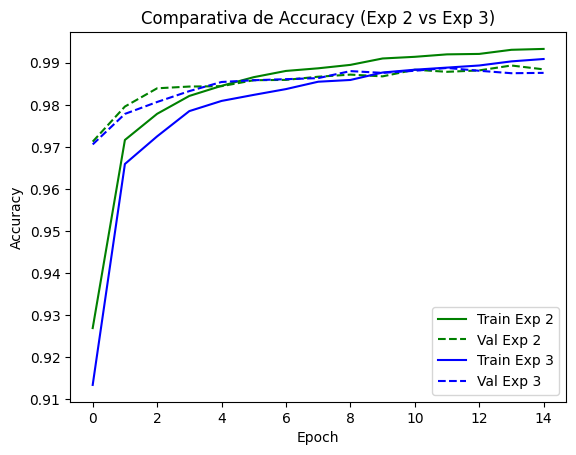

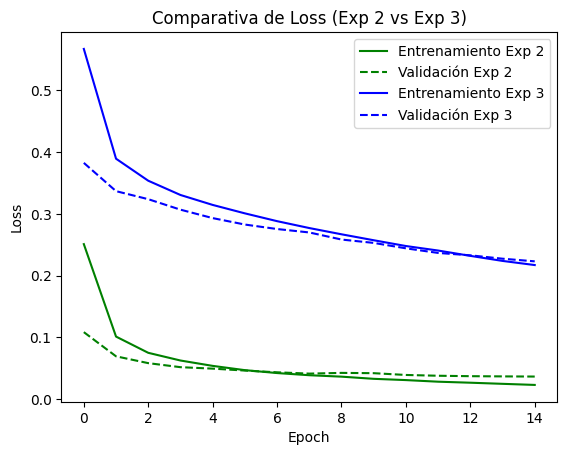

In [22]:
plot_compare_accs(history_cnn, history_cnn_exp3, name1="Exp 2", name2="Exp 3", title="Comparativa de Accuracy (Exp 2 vs Exp 3)")
plot_compare_losses(history_cnn, history_cnn_exp3, name1="Exp 2", name2="Exp 3", title="Comparativa de Loss (Exp 2 vs Exp 3)")

In [23]:
# Al comparar mis resultados entre el Experimento 2 (Dropout 0.3) y el 3
# (Dropout 0.5 + L2), he sacado estas conclusiones sobre cómo afectan las mejoras:

# 1. Adiós al Overfitting: En el experimento anterior todavía tenía una pequeña brecha
# entre Accuracy y Val_Accuracy. Ahora, al subir el Dropout al 50% y añadir L2,
# esa diferencia ha desaparecido: mis dos accuracy están casi calcadas (98.9%).
# He logrado que el modelo deje de memorizar y aprenda de verdad.

# 2. ¿Por qué ha subido el Loss?: He notado que el error (Loss) ha saltado de 0.03
# a 0.22, pero no es algo malo. Es el efecto directo de la técnica L2: como ahora
# penalizo los pesos demasiado grandes sumándolos al error, el valor final del Loss
# sube por pura matemática, aunque el modelo esté funcionando bien.
# Se penalizan los pesos demasiado grandes para evitar el Overfitting, queremos que
# el modelo aprenda a responder bien manteniendo pesos pequeños y cercanos a 0

# 3. Rendimiento final: El Experimento 3 es mucho más "robusto" y estable, pero
# creo que me he pasado un poco de frenada con la disciplina. Al combinar un
# Dropout tan alto con L2, el modelo está tan restringido que no llega a superar
# la precisión del Experimento 2. Es un modelo más sano, pero un pelín menos hábil.

## **Problemas**

#### 7) Dado el siguiente modelo, calcula de forma detallada el volumen de salida y los parámetros de **cada capa**. Desarrolla tu respuesta mediante cálculos matemáticos. (2.5 puntos)(RA6)

| Capa | Configuración | Cálculo salida | Volumen de salida | Nº Parámetros | Computación |
|------|---------------|----------------|-------------------|---------------|-------------|
| Input | 28×28×1 |—  | 28x28x1 | 0 parámetros | Nula |
| Conv2D | 16 filtros, 3×3, pad=0, ReLU | 26 | (26x26x16) | 160 parámetros | Alta |
| MaxPooling2D | pool 2×2, stride 2| 13 | (13x13x16) | 0 parámetros| Nula |
| Flatten | — | 13 × 13 × 16 = 2704 | 2704 | 0 parámetros | Nula |  |
| Dense | 128 neuronas, ReLU | — | 128 | 346240 parámetros | Alta |
| Dropout | 0.5 |—| 128 | 0 parámetros | Nula |  |
| Dense | 10 neuronas, Softmax |— | 10 | 1290 parámetros | Media |  |

**Total parámetros -->> 347690 parámetros**

Para cada capa indica: **volumen de salida** (alto × ancho × profundidad) y **número de parámetros** (con bias).

En cada capa indica el grado de computación necesaria indicando: Alta,media o nula, que vamos a necesitar para realizar la inferencia del modelo. Recuerda en rellenar "Total parámetros -->" del final de la tabla.


---



In [24]:
# =====================================================================
# FÓRMULAS GENERALES UTILIZADAS
# =====================================================================
# 1. Tamaño de salida Conv2D: O = ((W - K + 2P) / S) + 1
#    (W: Tamaño entrada, K: Tamaño Filtro, P: Padding, S: Stride)
#
# 2. Parámetros Conv2D: Param = ((Ancho_K * Alto_K * Canales_In) + 1_bias) * Filtros_Out
#
# 3. Tamaño de salida MaxPooling: O = W / K (si Stride == K)
#
# 4. Parámetros Capa Densa (Fully Connected): Param = (Entradas + 1_bias) * Neuronas_Out

# =====================================================================
# DESGLOSE CAPA POR CAPA
# =====================================================================

# --- 1. CAPA: Input ---
# Volumen de salida: 28x28x1 (Entrada de la imagen en escala de grises)
# Parámetros: 0 (Es la capa de entrada, no hay aprendizaje)
# Computación en inferencia: Nula

# --- 2. CAPA: Conv2D ---
# Volumen de salida (W × H × D) --> (26x26x16)
# Número de parámetros          --> 160 parámetros

# Desarrollo / Cálculo:
# W_out = (W_in − F + 2P) / S + 1
#
# W_in → Ancho de la imagen que entra a la capa
# F → Tamaño del Filtro o Kernel
# P → Padding
# S → Stride (Salto por el que se desplaza el filtro)
# +1 → Ajuste final para contar la primera posición del filtro

# W = (28 - 3 + 2 * 0) / 1 + 1 = 25 + 1 = 26
# H = Como la imagen es cuadrada (28x28), H_out también es 26
# D = Nº Filtros -> 16

# Params → (F x F x Cin + 1) x K
# F → Tamaño del Filtro o Kernel
# C_in → (Channels / Canales de entrada)

# Params = (3 x 3 x 1 + 1) x 16 = 10 x 16 = 10 x 16 = 160
# Computación en inferencia: Alta (Requiere múltiples multiplicaciones de matrices espaciales)

# --- 3. CAPA: MaxPooling2D ---
# Volumen de Entrada (26x26x16)

# Volumen de salida (W × H × D) --> (13x13x16)
# Número de parámetros          --> 0 parámetros

# Desarrollo / Cálculo:
# W_out = (W_in − F + 2P) / S + 1

# W = (26 - 2 + 2 * 0) / 2 + 1 = 24 / 2 + 1 = 12 + 1 = 13
# H = Como la imagen es cuadrada (28x28), H_out también es 13
# D = En Max Pooling la profundidad se mantiene igual, por lo que es 16

# Params → Max Pooling → 0
# Computación en inferencia: Nula/Media (Comparaciones de valores, mucho más ligero que Conv2D)

# --- 4. CAPA: Flatten ---
# Cálculo del aplanamiento: 13 * 13 * 16 = 2704
# Volumen de salida: Vector 1D de 2704 elementos
# Cálculo de Parámetros: 0 (Solo es un cambio en la forma de la matriz - reshape)
# Computación en inferencia: Nula (No hay operaciones matemáticas, solo movimiento en memoria)

# --- 5. CAPA: Dense (128) ---
# Volumen de salida: 128 (número de neuronas de la capa)
# Cálculo de Parámetros: (2704 entradas + 1 bias) * 128 neuronas = 2705 * 128 = 346,240 parámetros
# Computación en inferencia: Alta (Multiplicación de matrices grande: 2704 x 128)

# --- 6. CAPA: Dropout (0.5) ---
# Volumen de salida: 128 (Mantiene el mismo volumen que la capa anterior)
# Cálculo de Parámetros: 0 (No tiene pesos entrenables)
# Computación en inferencia: Nula (Durante la fase de inferencia/test, el dropout se desactiva y actúa como identidad)

# --- 7. CAPA: Dense (10) ---
# Volumen de salida: 10 (las clases del 0 al 9)
# Cálculo de Parámetros: (128 entradas + 1 bias) * 10 neuronas = 129 * 10 = 1,290 parámetros
# Computación en inferencia: Media (Multiplicación de matrices pequeña: 128 x 10)

# =====================================================================
# CÁLCULO DEL TOTAL DE PARÁMETROS
# =====================================================================
# Total = 160 (Conv) + 0 (MaxPool) + 0 (Flatten) + 346,240 (Dense 1) + 0 (Drop) + 1,290 (Dense 2)
# Total = 347,690 parámetros entrenables

#### Grafo de computación

Nuestras redes neuronales son grafos de computación. TensorFlow por dentro está formado por estos. En la siguiente imagen tienes un grafo de computación.

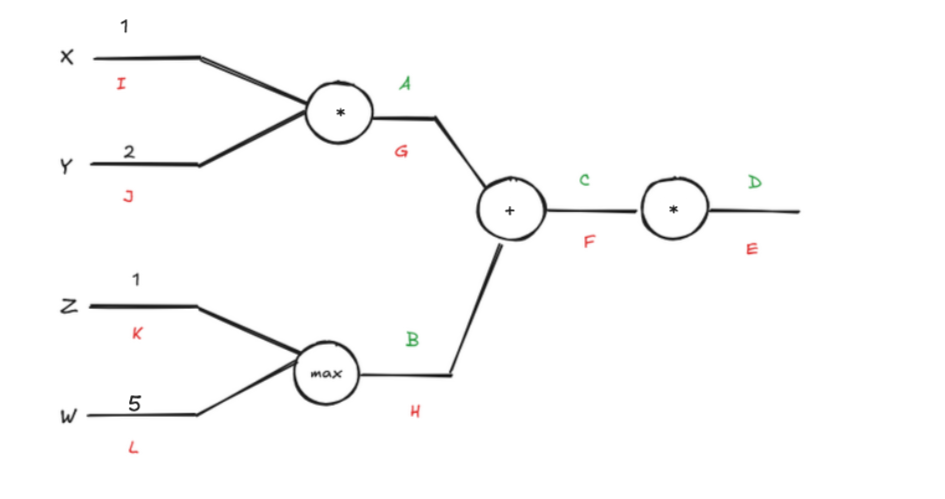

#### 8) A partir del grafo de computación de la figura, aplica el algoritmo de backpropagation. (1 puntos) (RA6)



Forward pass:
*  A = 2
*  B = 5
*  C = 7
*  D = 7

Backward pass:
*  E = 1
*  F = 1
*  G = 1
*  H = 1
*  I = 2
*  J = 1
*  K = 0 --> Al ser el perdedor recibe 0
*  L = 1 --> Al ser el ganador recibe todo



